# Content-Based Filtering with a Neural Network — Book Recommendation System

This notebook is my own re-implementation of the **content-based filtering with deep learning** lab from the *Machine Learning Specialization* (Course 3, Week 2). The original exercise builds a two-tower neural network on the MovieLens dataset. To make this genuinely my own work (and avoid reusing the course's dataset/utility files), I rebuilt the entire pipeline from scratch around a **synthetic "Book Club" dataset** that I generate myself in the notebook.

**The underlying machine learning idea is identical to the original lab:**

- Every **user** is described by a feature vector (how many books they've rated, their average rating, and their average rating *per genre*).
- Every **item** (book) is described by a feature vector (its publication year, its average rating, and which genres it belongs to).
- A **neural network with two towers** — one for users, one for items — learns to turn each feature vector into a 32-dimensional embedding.
- The embeddings are **L2-normalized** and combined with a **dot product** to predict a rating.
- Because items get their own learned embedding, we can also use it to find **"more books like this one"** — pure content-based similarity, no collaborative signal required.

No external data files or images are needed — everything (books, users, ratings) is generated in code with a fixed random seed, so the notebook runs top-to-bottom anywhere (local, Colab, or GitHub's notebook viewer) and always produces the same result.


## 1 - Packages

We use NumPy and Pandas for data wrangling, scikit-learn for scaling/splitting, TensorFlow/Keras for the neural network, and `tabulate` + Matplotlib for nicely displaying results.

In [1]:
import numpy as np
import numpy.ma as ma
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
import tabulate
import matplotlib.pyplot as plt

pd.set_option("display.precision", 2)
np.set_printoptions(precision=2, suppress=True)

print("TensorFlow version:", tf.__version__)

I0000 00:00:1790246755.260519     571 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790246755.300216     571 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1790246756.545252     571 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0


## 2 - Building a synthetic "Book Club" dataset

Instead of downloading a prepared dataset, we simulate one ourselves — this is a useful skill on its own, and it means the whole notebook is self-contained.

**The world we're simulating:**
- 10 genres: Fantasy, Mystery, Romance, SciFi, Biography, History, Horror, Comedy, Thriller, Children's.
- 500 books, each tagged with 1-3 genres, a publication year, and a hidden "true quality" score.
- 300 readers, each with a hidden genre-affinity vector — every reader secretly loves a couple of genres, dislikes a couple, and is lukewarm about the rest.
- A pile of star ratings (0.5-5.0) generated from `0.75 * (reader's affinity for the book's genres) + 0.25 * (book's quality) + noise`.

This mirrors how the original MovieLens-derived lab data was structured: real ratings, real genres, real per-user/per-item statistics — just generated instead of downloaded.

We fix the random seed so results are reproducible every time you run this notebook.

In [2]:
rng = np.random.default_rng(42)

GENRES = ['Fantasy', 'Mystery', 'Romance', 'SciFi', 'Biography',
          'History', 'Horror', 'Comedy', 'Thriller', 'Childrens']
N_GENRES = len(GENRES)
N_BOOKS  = 500
N_USERS  = 300

# word banks used to procedurally generate a plausible-looking title for each book
TITLE_PARTS = {
    'Fantasy':   (['Dragon', 'Shadow', 'Crown', 'Realm', 'Sorcerer'], ['Oath', 'Kingdom', 'Prophecy', 'Throne', 'Legacy']),
    'Mystery':   (['Silent', 'Hidden', 'Last', 'Vanishing', 'Secret'], ['Clue', 'Witness', 'Cipher', 'Alibi', 'Case']),
    'Romance':   (['Sweet', 'Forbidden', 'Endless', 'Unexpected', 'Whispered'], ['Promise', 'Affair', 'Letters', 'Summer', 'Heart']),
    'SciFi':     (['Quantum', 'Stellar', 'Neon', 'Orbital', 'Synthetic'], ['Horizon', 'Protocol', 'Drift', 'Genesis', 'Frontier']),
    'Biography': (['A Life', 'An Ordinary', 'The Untold', 'My', 'A Quiet'], ['Story', 'Journey', 'Legacy', 'Truth', 'Path']),
    'History':   (['The Fall of', 'The Rise of', 'Echoes of', 'Shadows of', 'The Age of'], ['Empires', 'Kingdoms', 'Nations', 'Revolution', 'Silence']),
    'Horror':    (['The Haunting of', 'The Curse of', 'Whispers in', 'The Night of', 'Beneath'], ['the House', 'the Woods', 'the Dark', 'the Grave', 'the Attic']),
    'Comedy':    (['The Accidental', 'A Very Awkward', 'My Terrible', 'The Unlikely', 'A Ridiculous'], ['Wedding', 'Vacation', 'Roommate', 'Disaster', 'Adventure']),
    'Thriller':  (['The Final', 'The Perfect', 'No Way', 'Deadly', 'The Last'], ['Countdown', 'Target', 'Escape', 'Alibi', 'Signal']),
    'Childrens': (['The Little', 'Bella the', 'Sammy and the', 'The Brave', 'Tiny'], ['Dragon', 'Bunny', 'Treehouse', 'Adventure', 'Star']),
}

_used_titles = set()

def make_title(rng, primary_genre):
    """Procedurally build a (roughly) unique title for a book, biased toward its main genre."""
    adjs, nouns = TITLE_PARTS[primary_genre]
    for _ in range(25):
        title = f"{rng.choice(adjs)} {rng.choice(nouns)}"
        if title not in _used_titles:
            _used_titles.add(title)
            return title
    n = 2
    while f"{title} (Vol. {n})" in _used_titles:
        n += 1
    title = f"{title} (Vol. {n})"
    _used_titles.add(title)
    return title

In [3]:
# --- generate the book catalog ---
book_ids = np.arange(3000, 3000 + N_BOOKS)
book_years = rng.integers(1950, 2024, N_BOOKS)
book_quality = np.clip(rng.normal(3.5, 0.6, N_BOOKS), 1.0, 5.0)   # hidden "true quality" of each book

book_genre_matrix = np.zeros((N_BOOKS, N_GENRES), dtype=np.float64)
book_primary_genre = []
for i in range(N_BOOKS):
    k = rng.integers(1, 4)  # every book has 1-3 genres
    chosen = rng.choice(N_GENRES, size=k, replace=False)
    book_genre_matrix[i, chosen] = 1.0
    book_primary_genre.append(GENRES[chosen[0]])

book_titles = [make_title(rng, g) for g in book_primary_genre]

print(f"Generated {N_BOOKS} books across {N_GENRES} genres.")
print("Example:", book_titles[0], "->", [GENRES[g] for g in range(N_GENRES) if book_genre_matrix[0, g] == 1.0])

Generated 500 books across 10 genres.
Example: The Rise of Silence -> ['History']


In [4]:
# --- generate the readers ---
user_ids = np.arange(1, N_USERS + 1)
user_affinity = np.zeros((N_USERS, N_GENRES))   # hidden "true" per-genre affinity for each reader

for u in range(N_USERS):
    base = np.clip(rng.normal(3.0, 0.3, N_GENRES), 0.5, 5.0)
    favorites = rng.choice(N_GENRES, size=2, replace=False)
    base[favorites] = np.clip(base[favorites] + 1.5, 0.5, 5.0)          # a couple of favorite genres
    disliked = rng.choice(N_GENRES, size=rng.integers(1, 3), replace=False)
    base[disliked] = np.clip(base[disliked] - 1.5, 0.5, 5.0)            # a couple of disliked genres
    user_affinity[u] = base

print(f"Generated {N_USERS} readers, each with their own hidden genre taste profile.")
print("Reader 0's affinity by genre:")
print(pd.Series(user_affinity[0], index=GENRES).round(2))

Generated 300 readers, each with their own hidden genre taste profile.
Reader 0's affinity by genre:
Fantasy      4.27
Mystery      2.85
Romance      3.65
SciFi        3.03
Biography    3.55
History      3.06
Horror       3.07
Comedy       2.91
Thriller     3.28
Childrens    3.41
dtype: float64


In [5]:
# --- generate ratings from the hidden reader/book model ---
records = []
for iu in range(N_USERS):
    n_rate = rng.integers(15, 60)                       # each reader rates 15-59 books
    chosen_books = rng.choice(N_BOOKS, size=n_rate, replace=False)
    for ib in chosen_books:
        genre_idx = np.where(book_genre_matrix[ib] == 1.0)[0]
        mean_affinity = user_affinity[iu, genre_idx].mean()
        raw = 0.75 * mean_affinity + 0.25 * book_quality[ib] + rng.normal(0, 0.35)
        rating = np.clip(raw, 0.5, 5.0)
        rating = round(rating * 2) / 2.0                 # snap to the nearest half-star
        records.append((user_ids[iu], book_ids[ib], rating))

ratings_df = pd.DataFrame(records, columns=['user_id', 'book_id', 'rating'])
print(f"Total ratings generated: {len(ratings_df)}")
ratings_df.head()

Total ratings generated: 10891


,user_id,book_id,rating
0,1,3318,4.0
1,1,3305,3.0
2,1,3367,3.0
3,1,3070,3.5
4,1,3101,3.5


## 3 - Turning raw ratings into content features

The whole point of *content-based* filtering (as opposed to collaborative filtering) is that we never use raw user/item IDs as a lookup table of learned embeddings. Instead, every user and every item is described purely by **content features**:

- **Book features:** publication year, average rating (across everyone), and its genre tags.
- **Reader features:** how many books they've rated, their average rating overall, and their average rating *within each genre*.

We compute these aggregate statistics directly from the ratings we just generated.

In [6]:
global_mean = ratings_df['rating'].mean()

book_ave = ratings_df.groupby('book_id')['rating'].mean().reindex(book_ids).fillna(global_mean).values
user_count = ratings_df.groupby('user_id')['rating'].count().reindex(user_ids).fillna(0).values
user_ave = ratings_df.groupby('user_id')['rating'].mean().reindex(user_ids).fillna(global_mean).values

book_id_to_idx = {bid: i for i, bid in enumerate(book_ids)}
user_id_to_idx = {uid: i for i, uid in enumerate(user_ids)}

# per-reader, per-genre average rating (0.0 if they've never rated a book in that genre)
genre_sum = np.zeros((N_USERS, N_GENRES))
genre_cnt = np.zeros((N_USERS, N_GENRES))
for row in ratings_df.itertuples():
    iu = user_id_to_idx[row.user_id]
    ib = book_id_to_idx[row.book_id]
    g_idx = np.where(book_genre_matrix[ib] == 1.0)[0]
    genre_sum[iu, g_idx] += row.rating
    genre_cnt[iu, g_idx] += 1

user_genre_ave = np.where(genre_cnt > 0, genre_sum / np.maximum(genre_cnt, 1), 0.0)

print("Computed book averages, reader averages, and per-genre reader averages.")

Computed book averages, reader averages, and per-genre reader averages.


In [7]:
# the full book catalog as feature vectors: [book_id, year, ave_rating, genre_1 ... genre_10]
item_vecs = np.column_stack([book_ids, book_years, book_ave, book_genre_matrix])

book_dict = {}
for i, bid in enumerate(book_ids):
    book_dict[bid] = {
        'title': book_titles[i],
        'genres': ", ".join([GENRES[g] for g in range(N_GENRES) if book_genre_matrix[i, g] == 1.0]),
        'year': int(book_years[i]),
        'ave_rating': round(float(book_ave[i]), 2),
    }

print(f"item_vecs shape: {item_vecs.shape}  (one row per unique book in the catalog)")

item_vecs shape: (500, 13)  (one row per unique book in the catalog)


## 4 - Building the training set

Just like the original lab, we build one training row **per rating**: the item feature vector for the book being rated, the user feature vector for the reader who rated it, and the rating itself as the target `y`.

We keep `book_id` / `user_id` as the first column(s) purely for bookkeeping (so we can look a title back up later) — they are explicitly **excluded** from what the network actually trains on. That's the difference between content-based filtering and an ID-embedding approach: the network only ever sees *content* features.

In [8]:
n_rows = len(ratings_df)
item_train = np.zeros((n_rows, item_vecs.shape[1]))
user_train = np.zeros((n_rows, 3 + N_GENRES))
y_train = np.zeros(n_rows)

for r, row in enumerate(ratings_df.itertuples()):
    ib = book_id_to_idx[row.book_id]
    iu = user_id_to_idx[row.user_id]
    item_train[r] = item_vecs[ib]
    user_train[r] = np.concatenate(([row.user_id, user_count[iu], user_ave[iu]], user_genre_ave[iu]))
    y_train[r] = row.rating

item_features = ['book_id', 'year', 'ave_rating'] + GENRES
user_features = ['user_id', 'rating_count', 'rating_ave'] + [f"ave_{g}" for g in GENRES]

# columns to SKIP when feeding the network (ids, and stats that would leak the target)
num_user_features = user_train.shape[1] - 3   # drop user id, rating count, rating ave
num_item_features = item_train.shape[1] - 1   # drop book id
u_s = 3   # user training columns start here
i_s = 1   # item training columns start here

print(f"Number of training examples: {len(item_train)}")
print(f"item_train shape: {item_train.shape}   -> {num_item_features} features used for training")
print(f"user_train shape: {user_train.shape}   -> {num_user_features} features used for training")

Number of training examples: 10891
item_train shape: (10891, 13)   -> 12 features used for training
user_train shape: (10891, 13)   -> 10 features used for training


In [9]:
print("Sample item rows (book_id / year / ave_rating / genre flags):")
display(pd.DataFrame(item_train[:5], columns=item_features))

print("\nSample user rows (user_id / rating_count / rating_ave / per-genre averages):")
display(pd.DataFrame(user_train[:5], columns=user_features))

print(f"\ny_train[:5]: {y_train[:5]}")

Sample item rows (book_id / year / ave_rating / genre flags):


,book_id,year,ave_rating,Fantasy,Mystery,Romance,SciFi,Biography,History,Horror,Comedy,Thriller,Childrens
0,3318.0,2019.0,3.24,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3305.0,1960.0,3.17,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,3367.0,1973.0,2.86,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,3070.0,2008.0,2.91,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,3101.0,1964.0,2.81,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0



Sample user rows (user_id / rating_count / rating_ave / per-genre averages):


,user_id,rating_count,rating_ave,ave_Fantasy,ave_Mystery,ave_Romance,ave_SciFi,ave_Biography,ave_History,ave_Horror,ave_Comedy,ave_Thriller,ave_Childrens
0,1.0,46.0,3.3,3.79,3.18,3.59,3.35,3.36,3.08,3.19,3.17,3.25,3.21
1,1.0,46.0,3.3,3.79,3.18,3.59,3.35,3.36,3.08,3.19,3.17,3.25,3.21
2,1.0,46.0,3.3,3.79,3.18,3.59,3.35,3.36,3.08,3.19,3.17,3.25,3.21
3,1.0,46.0,3.3,3.79,3.18,3.59,3.35,3.36,3.08,3.19,3.17,3.25,3.21
4,1.0,46.0,3.3,3.79,3.18,3.59,3.35,3.36,3.08,3.19,3.17,3.25,3.21



y_train[:5]: [4.  3.  3.  3.5 3.5]


## 5 - Scaling and splitting

Neural networks train much better when input features are on comparable scales. We use `StandardScaler` on both the item and user feature matrices, and scale the target ratings into `[-1, 1]` with `MinMaxScaler` (matching the original lab's approach). Then we hold out 20% of the data as a test set.

In [10]:
item_train_unscaled = item_train
user_train_unscaled = user_train
y_train_unscaled = y_train

scalerItem = StandardScaler()
scalerItem.fit(item_train)
item_train = scalerItem.transform(item_train)

scalerUser = StandardScaler()
scalerUser.fit(user_train)
user_train = scalerUser.transform(user_train)

scalerTarget = MinMaxScaler((-1, 1))
scalerTarget.fit(y_train.reshape(-1, 1))
y_train = scalerTarget.transform(y_train.reshape(-1, 1))

# sanity check: scaling is perfectly reversible
print(np.allclose(item_train_unscaled, scalerItem.inverse_transform(item_train)))
print(np.allclose(user_train_unscaled, scalerUser.inverse_transform(user_train)))

True
True


In [11]:
item_train, item_test = train_test_split(item_train, train_size=0.80, shuffle=True, random_state=1)
user_train, user_test = train_test_split(user_train, train_size=0.80, shuffle=True, random_state=1)
y_train, y_test = train_test_split(y_train, train_size=0.80, shuffle=True, random_state=1)

print(f"item_train shape: {item_train.shape}, item_test shape: {item_test.shape}")

item_train shape: (8712, 13), item_test shape: (2179, 13)


## 6 - The two-tower neural network

This is the heart of content-based filtering with deep learning:

- A **user tower** (`user_NN`) turns a reader's feature vector into a 32-dimensional embedding `v_u`.
- An **item tower** (`item_NN`) turns a book's feature vector into a 32-dimensional embedding `v_m`.
- Both embeddings are **L2-normalized** (so only their *direction* matters, not their magnitude).
- The predicted rating is the **dot product** `v_u . v_m` — the more aligned a reader's and a book's embeddings are, the higher the predicted rating.

Both towers use the same architecture (`Dense(256, relu) -> Dense(128, relu) -> Dense(32)`), but they are two **separate** networks with separate weights — they just happen to end up in a shared 32-dimensional embedding space.

In [12]:
num_outputs = 32
tf.random.set_seed(1)

user_NN = tf.keras.models.Sequential([
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(num_outputs),
])

item_NN = tf.keras.models.Sequential([
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(num_outputs),
])

# user tower
input_user = tf.keras.layers.Input(shape=(num_user_features,))
vu = user_NN(input_user)
vu = tf.keras.layers.Lambda(lambda x: tf.linalg.l2_normalize(x, axis=1), output_shape=lambda s: s)(vu)

# item tower
input_item = tf.keras.layers.Input(shape=(num_item_features,))
vm = item_NN(input_item)
vm = tf.keras.layers.Lambda(lambda x: tf.linalg.l2_normalize(x, axis=1), output_shape=lambda s: s)(vm)

# combine with a dot product
output = tf.keras.layers.Dot(axes=1)([vu, vm])
model = tf.keras.Model([input_user, input_item], output)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 12)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 32)        │     39,840 │ input_layer[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 32)        │     40,352 │ input_layer_2[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 32)        │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 32)        │          0 │ sequential_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, 1)         │          0 │ lambda[0][0],     │
│                     │                   │            │ lambda_1[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 80,192 (313.25 KB)

 Trainable params: 80,192 (313.25 KB)

 Non-trainable params: 0 (0.00 B)

## 7 - Training

We use mean squared error as the loss (since we're predicting a continuous rating) and the Adam optimizer.

> **Note on the `Lambda` layer:** the original course lab calls `tf.linalg.l2_normalize` directly on a Keras tensor, which worked under the older Keras 2 API. Newer Keras 3 requires TensorFlow ops on symbolic tensors to be wrapped in a proper layer, so I wrap the normalization in a `Lambda` layer — same math, just future-proofed for current TensorFlow versions.

In [13]:
tf.random.set_seed(1)
cost_fn = tf.keras.losses.MeanSquaredError()
opt = keras.optimizers.Adam(learning_rate=0.01)
model.compile(optimizer=opt, loss=cost_fn)

history = model.fit(
    [user_train[:, u_s:], item_train[:, i_s:]],
    y_train,
    epochs=25,
    verbose=2,
)

Epoch 1/25


273/273 - 2s - 6ms/step - loss: 0.0709


Epoch 2/25


273/273 - 1s - 2ms/step - loss: 0.0613


Epoch 3/25


...

273/273 - 1s - 2ms/step - loss: 0.0251


Epoch 24/25


273/273 - 1s - 2ms/step - loss: 0.0247


Epoch 25/25


273/273 - 1s - 2ms/step - loss: 0.0243


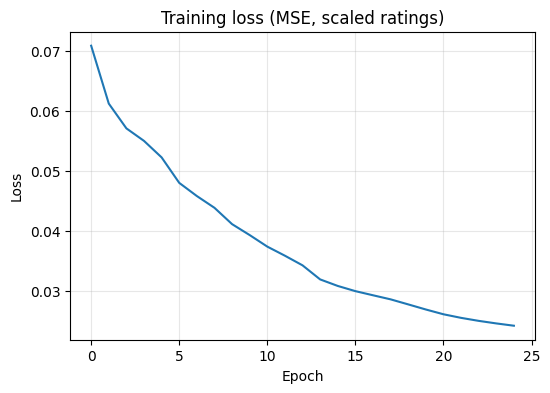

In [14]:
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'])
plt.title("Training loss (MSE, scaled ratings)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.show()

Evaluate on the held-out test set. A test loss close to the training loss tells us the model has not badly overfit.

In [15]:
test_loss = model.evaluate([user_test[:, u_s:], item_test[:, i_s:]], y_test)
print(f"Test loss: {test_loss:.4f}")

 1/69 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - loss: 0.0414

49/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0385  

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0380


Test loss: 0.0380


## 8 - Recommending books to a brand-new reader

One advantage of content-based filtering is that it works for a **cold-start** reader who has never rated anything: we just need to know a bit about their taste (e.g. from a quick onboarding quiz), build a feature vector for them, and ask the model to score every book in the catalog.

Below, we create a new reader who says they love **Fantasy** and **SciFi**, and ask the model for its top 10 picks.

In [16]:
def gen_user_vecs(user_vec, num_items):
    """Repeat a single user feature vector once per item, so we can score the whole catalog at once."""
    return np.tile(user_vec, (num_items, 1))

new_user_id = 9000
new_rating_count = 3
new_rating_ave = 0.0
new_affinities = {g: 0.0 for g in GENRES}
new_affinities['Fantasy'] = 5.0
new_affinities['SciFi'] = 4.5

user_vec = np.array([[new_user_id, new_rating_count, new_rating_ave] + [new_affinities[g] for g in GENRES]])
user_vecs = gen_user_vecs(user_vec, len(item_vecs))

suser_vecs = scalerUser.transform(user_vecs)
sitem_vecs = scalerItem.transform(item_vecs)

y_p = model.predict([suser_vecs[:, u_s:], sitem_vecs[:, i_s:]], verbose=0)
y_pu = scalerTarget.inverse_transform(y_p)

sorted_index = np.argsort(-y_pu, axis=0).reshape(-1).tolist()
sorted_ypu = y_pu[sorted_index]
sorted_items = item_vecs[sorted_index]

print("Top 10 recommendations for a brand-new Fantasy/SciFi fan:\n")
rows = [["Predicted rating", "Title", "Genres"]]
for i in range(10):
    bid = int(sorted_items[i, 0])
    d = book_dict[bid]
    rows.append([f"{sorted_ypu[i, 0]:.2f}", d['title'], d['genres']])
print(tabulate.tabulate(rows, headers="firstrow", tablefmt="github"))

Top 10 recommendations for a brand-new Fantasy/SciFi fan:

|   Predicted rating | Title                     | Genres                  |
|--------------------|---------------------------|-------------------------|
|               4.1  | Sorcerer Kingdom          | Fantasy, SciFi          |
|               4    | Orbital Genesis           | Fantasy, SciFi          |
|               3.96 | Dragon Throne             | Fantasy                 |
|               3.96 | Dragon Prophecy (Vol. 2)  | Fantasy                 |
|               3.92 | The Accidental Wedding    | Fantasy, SciFi, Comedy  |
|               3.9  | Crown Throne              | Fantasy                 |
|               3.9  | Realm Oath (Vol. 2)       | Fantasy                 |
|               3.83 | Sorcerer Oath             | Fantasy                 |
|               3.8  | Neon Protocol             | Fantasy, Mystery, SciFi |
|               3.76 | Quantum Protocol (Vol. 2) | SciFi                   |


## 9 - Checking predictions for an existing reader

Now let's look at a reader who is already in our dataset, and compare the model's predicted rating against what they actually rated, for books they've already read.

In [17]:
def get_user_vecs(user_id, user_train_unscaled, item_vecs, ratings_df, book_id_to_idx):
    mask = user_train_unscaled[:, 0] == user_id
    row = user_train_unscaled[mask][0]
    urated = ratings_df[ratings_df.user_id == user_id]
    rated_book_ids = urated.book_id.values
    idxs = [book_id_to_idx[b] for b in rated_book_ids]
    items = item_vecs[idxs]
    y_actual = urated.rating.values
    user_vecs = gen_user_vecs(row.reshape(1, -1), len(items))
    return user_vecs, items, y_actual

uid = user_ids[2]
user_vecs2, items2, y_actual2 = get_user_vecs(uid, user_train_unscaled, item_vecs, ratings_df, book_id_to_idx)

suser2 = scalerUser.transform(user_vecs2)
sitem2 = scalerItem.transform(items2)
y_p2 = model.predict([suser2[:, u_s:], sitem2[:, i_s:]], verbose=0)
y_pu2 = scalerTarget.inverse_transform(y_p2).reshape(-1)

order = np.argsort(-y_pu2)
print(f"Reader {uid}: predicted vs. actual ratings on books they've already read\n")
rows = [["Predicted", "Actual", "Title", "Genres"]]
for i in order[:10]:
    bid = int(items2[i, 0])
    d = book_dict[bid]
    rows.append([f"{y_pu2[i]:.2f}", f"{y_actual2[i]:.2f}", d['title'], d['genres']])
print(tabulate.tabulate(rows, headers="firstrow", tablefmt="github"))

Reader 3: predicted vs. actual ratings on books they've already read

|   Predicted |   Actual | Title                            | Genres                    |
|-------------|----------|----------------------------------|---------------------------|
|        4.04 |      5   | Sweet Heart                      | Romance                   |
|        3.84 |      4   | The Night of the Woods (Vol. 3)  | Horror                    |
|        3.83 |      4.5 | The Rise of Revolution           | History                   |
|        3.72 |      3.5 | The Curse of the Grave (Vol. 2)  | Mystery, Horror           |
|        3.63 |      3.5 | Shadows of Silence               | Fantasy, History, Horror  |
|        3.57 |      4   | Whispers in the House (Vol. 2)   | Romance, Horror, Thriller |
|        3.56 |      3.5 | A Ridiculous Adventure (Vol. 2)  | Mystery, Comedy, Thriller |
|        3.56 |      3   | The Accidental Vacation (Vol. 2) | Mystery, Comedy, Thriller |
|        3.53 |      3   | The

## 10 - Finding similar books from the learned embeddings

The item tower (`item_NN`) gives every book a 32-dimensional embedding. Books with similar embeddings should be similar in content — this gives us a **"more like this"** feature for free, without needing any user at all.

First, a small helper: the squared distance between two vectors.

In [18]:
def sq_dist(a, b):
    """Squared Euclidean distance between two equal-length vectors."""
    return np.sum(np.square(a - b))

a1 = np.array([1.0, 2.0, 3.0]); b1 = np.array([1.0, 2.0, 3.0])
a2 = np.array([1.1, 2.1, 3.1]); b2 = np.array([1.0, 2.0, 3.0])
a3 = np.array([0, 1, 0]);       b3 = np.array([1, 0, 0])

print(f"squared distance between a1 and b1: {sq_dist(a1, b1):.3f}")
print(f"squared distance between a2 and b2: {sq_dist(a2, b2):.3f}")
print(f"squared distance between a3 and b3: {sq_dist(a3, b3):.3f}")

squared distance between a1 and b1: 0.000
squared distance between a2 and b2: 0.030
squared distance between a3 and b3: 2.000


Next, we build a small model that reuses the already-trained `item_NN` to turn every book in the catalog into its embedding vector.

In [19]:
input_item_m = tf.keras.layers.Input(shape=(num_item_features,))
vm_m = item_NN(input_item_m)   # reuse the trained item tower
vm_m = tf.keras.layers.Lambda(lambda x: tf.linalg.l2_normalize(x, axis=1), output_shape=lambda s: s)(vm_m)
model_m = tf.keras.Model(input_item_m, vm_m)
model_m.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 32)             │        40,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 32)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,352 (157.62 KB)

 Trainable params: 40,352 (157.62 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
scaled_item_vecs = scalerItem.transform(item_vecs)
vms = model_m.predict(scaled_item_vecs[:, i_s:], verbose=0)
print(f"All item embeddings shape: {vms.shape}")

All item embeddings shape: (500, 32)


Finally, for a sample of books we compute the squared distance to every other book and report the closest match. We mask the diagonal so a book is never "most similar" to itself.

In [21]:
count = 30  # number of books to show
dim = len(vms)
dist = np.zeros((count, dim))
for i in range(count):
    for j in range(dim):
        dist[i, j] = sq_dist(vms[i, :], vms[j, :])

# mask each row's own index so a book can't be its own "most similar" match
m_dist = ma.masked_array(dist, mask=(np.arange(dim)[None, :] == np.arange(count)[:, None]))

rows = [["Book", "Genres", "Most similar book", "Genres"]]
for i in range(count):
    min_idx = np.argmin(m_dist[i])
    b1 = int(item_vecs[i, 0])
    b2 = int(item_vecs[min_idx, 0])
    rows.append([book_dict[b1]['title'], book_dict[b1]['genres'],
                 book_dict[b2]['title'], book_dict[b2]['genres']])

print(tabulate.tabulate(rows, headers="firstrow", tablefmt="github"))

| Book                      | Genres                        | Most similar book               | Genres                        |
|---------------------------|-------------------------------|---------------------------------|-------------------------------|
| The Rise of Silence       | History                       | Echoes of Kingdoms              | History                       |
| The Fall of Silence       | History                       | Echoes of Empires               | History                       |
| Realm Legacy              | Fantasy, Biography, Horror    | An Ordinary Path (Vol. 2)       | Biography, Horror             |
| A Quiet Journey           | Biography, History            | An Ordinary Truth (Vol. 2)      | Biography, History            |
| The Last Countdown        | Horror, Thriller, Childrens   | The Perfect Escape              | Horror, Thriller, Childrens   |
| Bella the Bunny           | Childrens                     | The Little Dragon               | Children

The matches are almost always in the same genre(s), even though the network was never told "match same-genre books" directly — it *learned* that genre similarity predicts rating similarity, purely from the rating data.

## 11 - Wrap-up

What this notebook demonstrates, end-to-end:

- How to engineer **content features** for users and items out of raw ratings (no ID embeddings).
- A **two-tower neural network** architecture that maps users and items into a shared embedding space.
- Combining embeddings with a **dot product**, after **L2-normalization**, to predict a rating.
- Using the trained model for **cold-start recommendations** (a brand-new reader) and for **sanity-checking predictions** against an existing reader's history.
- Reusing just the **item tower** to build a **content-based similarity search** ("more books like this") from the learned embeddings.

**Ideas to extend this project further:**
- Swap in a real dataset (e.g. Goodreads or Book-Crossing) using the same feature pipeline.
- Add more item features (page count, author, language) or user features (reading pace, preferred length).
- Try a bigger/smaller embedding dimension and compare test loss.
- Combine this content-based score with a collaborative-filtering score (hybrid recommender).
